In [1]:
import elecboltz
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

# matplotlib settings
# reset defaults
mpl.rcdefaults()
# font
mpl.rcParams['font.size'] = 16
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['pdf.fonttype'] = 3
# plotting
mpl.rcParams['lines.linewidth'] = 3
mpl.rcParams['lines.markersize'] = 20
mpl.rcParams['axes.formatter.useoffset'] = False

In [2]:
params = {
    'a': 3.75,
    'b': 3.75,
    'c': 13.2,
    'energy_scale': 160,
    'band_params': {'mu': -0.82439881, 't': 1, 'tp': -0.13642799,
                    'tpp': 0.06816836, 'tz': 0.06512192},
    'resolution': 41,
    'periodic': 2,
    'domain_size': [1.0, 1.0, 2.0],
    'Bamp': 0,
    'scattering_kernel_names': ['isotropic'],
    'scattering_kernel_params': [{'C_0': 3.0}]
}
band = elecboltz.BandStructure(**elecboltz.easy_params(params))
band.discretize()

In [3]:
isotropic_scats = np.linspace(1.0, 5.0, 100)
isotropic_rhos = np.empty_like(isotropic_scats)
for i, C_0 in enumerate(isotropic_scats):
    params['scattering_kernel_params'] = [{'C_0': C_0}]
    cond = elecboltz.Conductivity(band, **elecboltz.easy_params(params))
    cond.calculate()
    rho = np.linalg.inv(cond.sigma)
    isotropic_rhos[i] = rho[0, 0]

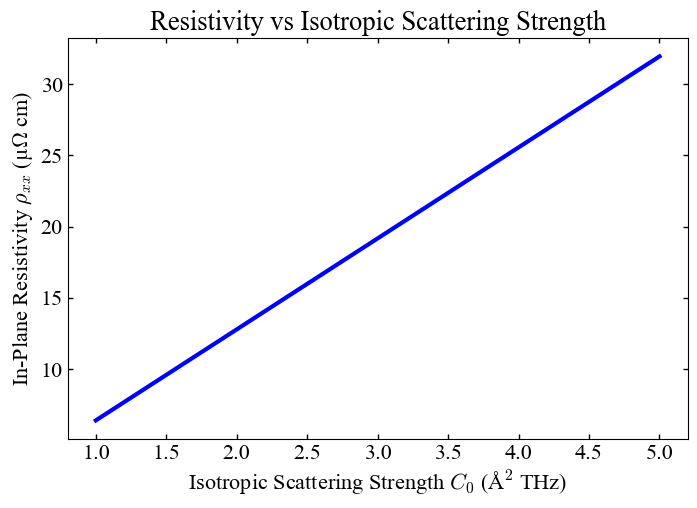

In [4]:
plt.plot(isotropic_scats, 1e8 * isotropic_rhos, color="blue")
plt.title("Resistivity vs Isotropic Scattering Strength")
plt.xlabel("Isotropic Scattering Strength $C_0$ (Å$^2$ THz)")
plt.ylabel("In-Plane Resistivity $\\rho_{xx}$ (µ$\\Omega$ cm)")
plt.savefig("Kernel/Forward vs Backward/isotropic_dependence.pdf",
            bbox_inches='tight')
plt.show()

In [3]:
forward_scattering_strengths = np.linspace(0.1, 10.0, 100)
forward_rhos = np.empty_like(forward_scattering_strengths)
params['scattering_kernel_names'] = ['isotropic', 'forward_phi']
for i, C_f in enumerate(forward_scattering_strengths):
    params['scattering_kernel_params'] = [
        {'C_0': 0.0}, {'C_f': C_f, 'sigma_f': 0.3},
        {'rank': 20, 'low_res': 21}]
    cond = elecboltz.Conductivity(band, **elecboltz.easy_params(params))
    cond.calculate()
    rho = np.linalg.inv(cond.sigma)
    forward_rhos[i] = rho[0, 0]

In [4]:
backward_scattering_strengths = np.linspace(0.1, 10.0, 100)
backward_rhos = np.empty_like(backward_scattering_strengths)
params['scattering_kernel_names'] = ['isotropic', 'backward_phi']
for i, C_b in enumerate(backward_scattering_strengths):
    params['scattering_kernel_params'] = [
        {'C_0': 0.0}, {'C_b': C_b, 'sigma_b': 0.3},
        {'rank': 20, 'low_res': 21}]
    cond = elecboltz.Conductivity(band, **elecboltz.easy_params(params))
    cond.calculate()
    rho = np.linalg.inv(cond.sigma)
    backward_rhos[i] = rho[0, 0]

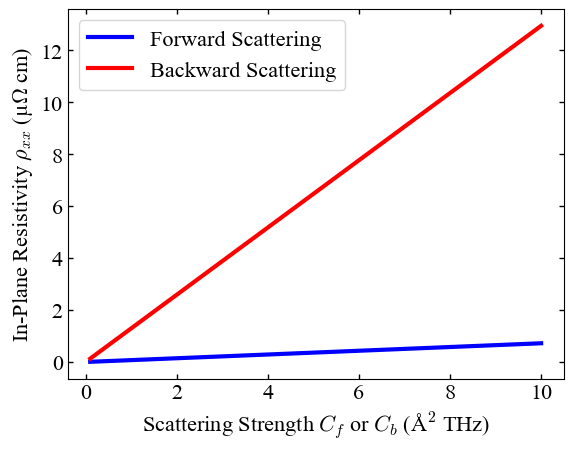

In [5]:
plt.plot(forward_scattering_strengths, 1e8 * forward_rhos, color="blue",
         label="Forward Scattering")
plt.plot(backward_scattering_strengths, 1e8 * backward_rhos, color="red",
         label="Backward Scattering")
plt.legend()
plt.xlabel("Scattering Strength $C_f$ or $C_b$ (Å$^2$ THz)")
plt.ylabel("In-Plane Resistivity $\\rho_{xx}$ (µ$\\Omega$ cm)")
plt.savefig("Kernel/Forward vs Backward/strength_comparison_no_isotropic.pdf",
            bbox_inches='tight')
plt.show()

In [6]:
forward_scattering_strengths = np.linspace(0.1, 10.0, 100)
forward_rhos = np.empty_like(forward_scattering_strengths)
params['scattering_kernel_names'] = ['isotropic', 'forward_phi']
for i, C_f in enumerate(forward_scattering_strengths):
    params['scattering_kernel_params'] = [
        {'C_0': 3.0}, {'C_f': C_f, 'sigma_f': 0.3},
        {'rank': 20, 'low_res': 21}]
    cond = elecboltz.Conductivity(band, **elecboltz.easy_params(params))
    cond.calculate()
    rho = np.linalg.inv(cond.sigma)
    forward_rhos[i] = rho[0, 0]

In [7]:
backward_scattering_strengths = np.linspace(0.1, 10.0, 100)
backward_rhos = np.empty_like(backward_scattering_strengths)
params['scattering_kernel_names'] = ['isotropic', 'backward_phi']
for i, C_b in enumerate(backward_scattering_strengths):
    params['scattering_kernel_params'] = [
        {'C_0': 3.0}, {'C_b': C_b, 'sigma_b': 0.3},
        {'rank': 20, 'low_res': 21}]
    cond = elecboltz.Conductivity(band, **elecboltz.easy_params(params))
    cond.calculate()
    rho = np.linalg.inv(cond.sigma)
    backward_rhos[i] = rho[0, 0]

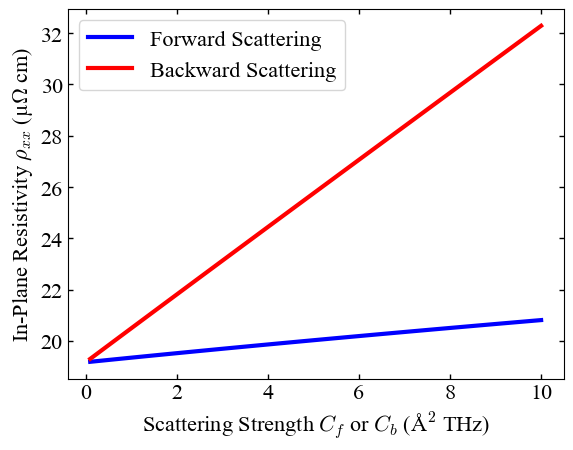

In [8]:
plt.plot(forward_scattering_strengths, 1e8 * forward_rhos, color="blue",
         label="Forward Scattering")
plt.plot(backward_scattering_strengths, 1e8 * backward_rhos, color="red",
         label="Backward Scattering")
plt.legend()
plt.xlabel("Scattering Strength $C_f$ or $C_b$ (Å$^2$ THz)")
plt.ylabel("In-Plane Resistivity $\\rho_{xx}$ (µ$\\Omega$ cm)")
plt.savefig("Kernel/Forward vs Backward/strength_comparison_with_isotropic.pdf",
            bbox_inches='tight')
plt.show()

In [9]:
forward_scattering_widths = np.linspace(0.3, 2.0, 100)
forward_rhos = np.empty_like(forward_scattering_widths)
params['scattering_kernel_names'] = ['isotropic', 'forward_phi']
for i, sigma_f in enumerate(forward_scattering_widths):
    params['scattering_kernel_params'] = [
        {'C_0': 0.0}, {'C_f': 1.0, 'sigma_f': sigma_f},
        {'rank': 20, 'low_res': 21}]
    cond = elecboltz.Conductivity(band, **elecboltz.easy_params(params))
    cond.calculate()
    rho = np.linalg.inv(cond.sigma)
    forward_rhos[i] = rho[0, 0]

In [10]:
backward_scattering_widths = np.linspace(0.3, 2.0, 100)
backward_rhos = np.empty_like(backward_scattering_widths)
params['scattering_kernel_names'] = ['isotropic', 'backward_phi']
for i, sigma_b in enumerate(backward_scattering_widths):
    params['scattering_kernel_params'] = [
        {'C_0': 0.0}, {'C_b': 1.0, 'sigma_b': sigma_b},
        {'rank': 20, 'low_res': 21}]
    cond = elecboltz.Conductivity(band, **elecboltz.easy_params(params))
    cond.calculate()
    rho = np.linalg.inv(cond.sigma)
    backward_rhos[i] = rho[0, 0]

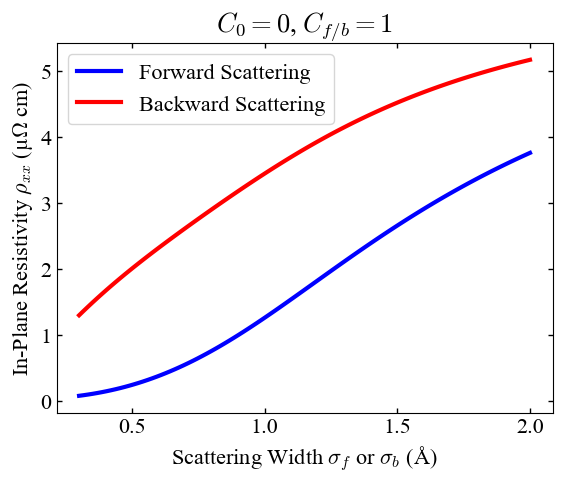

In [11]:
plt.plot(forward_scattering_widths, 1e8 * forward_rhos, color="blue",
         label="Forward Scattering")
plt.plot(backward_scattering_widths, 1e8 * backward_rhos, color="red",
         label="Backward Scattering")
plt.legend()
plt.xlabel("Scattering Width $\\sigma_f$ or $\\sigma_b$ (Å)")
plt.ylabel("In-Plane Resistivity $\\rho_{xx}$ (µ$\\Omega$ cm)")
plt.title("$C_0=0$, $C_{f/b}=1$")
plt.savefig("Kernel/Forward vs Backward/width_comparison.pdf",
            bbox_inches='tight')
plt.show()

In [12]:
forward_scattering_widths = np.linspace(0.3, 2.0, 100)
forward_rhos = np.empty_like(forward_scattering_widths)
params['scattering_kernel_names'] = ['isotropic', 'forward_phi']
for i, sigma_f in enumerate(forward_scattering_widths):
    params['scattering_kernel_params'] = [
        {'C_0': 0.0}, {'C_f': 1/sigma_f, 'sigma_f': sigma_f},
        {'rank': 20, 'low_res': 21}]
    cond = elecboltz.Conductivity(band, **elecboltz.easy_params(params))
    cond.calculate()
    rho = np.linalg.inv(cond.sigma)
    forward_rhos[i] = rho[0, 0]

In [13]:
backward_scattering_widths = np.linspace(0.3, 2.0, 100)
backward_rhos = np.empty_like(backward_scattering_widths)
params['scattering_kernel_names'] = ['isotropic', 'backward_phi']
for i, sigma_b in enumerate(backward_scattering_widths):
    params['scattering_kernel_params'] = [
        {'C_0': 0.0}, {'C_b': 1/sigma_b, 'sigma_b': sigma_b},
        {'rank': 20, 'low_res': 21}]
    cond = elecboltz.Conductivity(band, **elecboltz.easy_params(params))
    cond.calculate()
    rho = np.linalg.inv(cond.sigma)
    backward_rhos[i] = rho[0, 0]

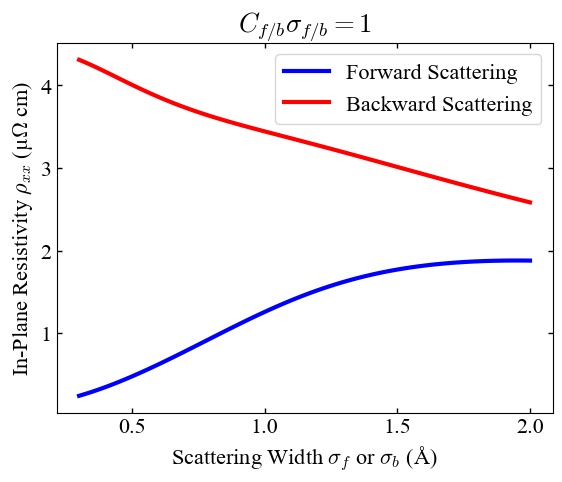

In [14]:
plt.plot(forward_scattering_widths, 1e8 * forward_rhos, color="blue",
         label="Forward Scattering")
plt.plot(backward_scattering_widths, 1e8 * backward_rhos, color="red",
         label="Backward Scattering")
plt.legend()
plt.xlabel("Scattering Width $\\sigma_f$ or $\\sigma_b$ (Å)")
plt.ylabel("In-Plane Resistivity $\\rho_{xx}$ (µ$\\Omega$ cm)")
plt.title("$C_{f/b}\\sigma_{f/b} = 1$")
plt.savefig("Kernel/Forward vs Backward/width_constant_product_comparison.pdf",
            bbox_inches='tight')
plt.show()

In [3]:
forward_scattering_strengths = np.linspace(0.1, 10.0, 100)
forward_rhos = np.empty_like(forward_scattering_strengths)
params['scattering_kernel_names'] = ['isotropic', 'forward_phi']
for i, C_f in enumerate(forward_scattering_strengths):
    params['scattering_kernel_params'] = [
        {'C_0': 5.0}, {'C_f': C_f, 'sigma_f': 0.5},
        {'rank': 15, 'low_res': 21}]
    cond = elecboltz.Conductivity(band, **elecboltz.easy_params(params))
    cond.calculate()
    rho = np.linalg.inv(cond.sigma)
    forward_rhos[i] = rho[2, 2]

In [4]:
backward_scattering_strengths = np.linspace(0.1, 10.0, 100)
backward_rhos = np.empty_like(backward_scattering_strengths)
params['scattering_kernel_names'] = ['isotropic', 'backward_phi']
for i, C_b in enumerate(backward_scattering_strengths):
    params['scattering_kernel_params'] = [
        {'C_0': 5.0}, {'C_b': C_b, 'sigma_b': 0.5},
        {'rank': 15, 'low_res': 21}]
    cond = elecboltz.Conductivity(band, **elecboltz.easy_params(params))
    cond.calculate()
    rho = np.linalg.inv(cond.sigma)
    backward_rhos[i] = rho[2, 2]

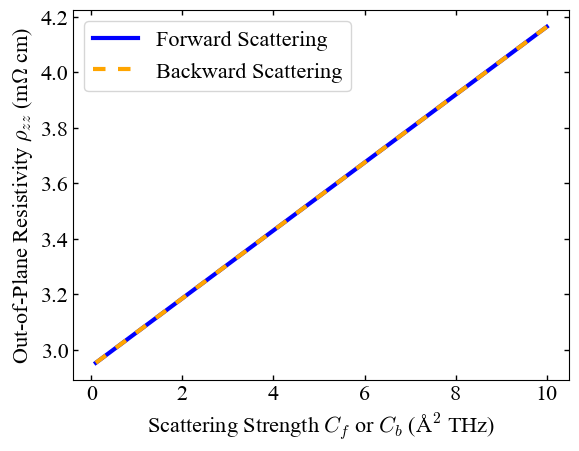

In [7]:
plt.plot(forward_scattering_strengths, 1e5 * forward_rhos, color="blue",
         label="Forward Scattering")
plt.plot(backward_scattering_strengths, 1e5 * backward_rhos, color="orange",
         label="Backward Scattering", linestyle=(0, (3, 3)))
plt.legend()
plt.xlabel("Scattering Strength $C_f$ or $C_b$ (Å$^2$ THz)")
plt.ylabel("Out-of-Plane Resistivity $\\rho_{zz}$ (m$\\Omega$ cm)")
plt.savefig("Kernel/Forward vs Backward/strength_comparison_out_of_plane.pdf",
            bbox_inches='tight')
plt.show()